In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(f"sample_data//california_housing_test.csv")
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
5,-119.56,36.51,37.0,1018.0,213.0,663.0,204.0,1.6635,67000.0
6,-121.43,38.63,43.0,1009.0,225.0,604.0,218.0,1.6641,67000.0
7,-120.65,35.48,19.0,2310.0,471.0,1341.0,441.0,3.2250,166900.0
8,-122.84,38.40,15.0,3080.0,617.0,1446.0,599.0,3.6696,194400.0
9,-118.02,34.08,31.0,2402.0,632.0,2830.0,603.0,2.3333,164200.0


In [26]:
df.shape

(3000, 10)

In [27]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,z_score
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000,3.000000e+03
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500,4.855375e-17
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747,1.000000e+00
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000,-1.335199e+00
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000,-5.935920e-01
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000,-2.200520e-01
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000,2.937365e-01
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000,1.215055e+01


In [28]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
z_score,0


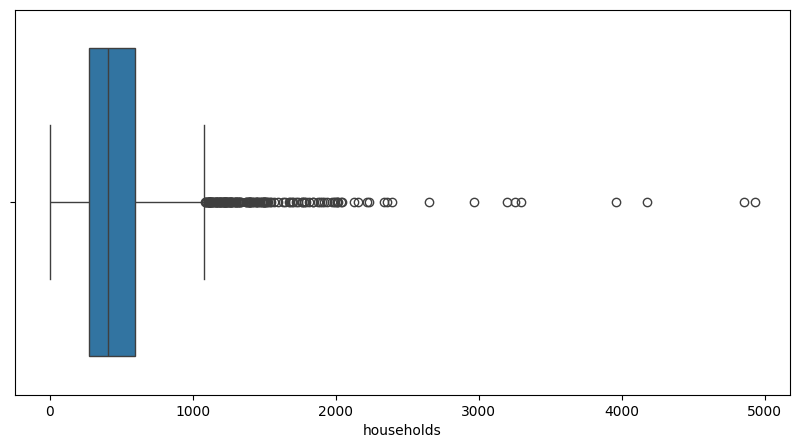

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['households'])
plt.show()

# plt.plot(['a','b','c','d','e'],[1,2,3,5,7])
# plt.title('my title')
# plt.xlabel('x label')
# plt.ylabel('y label')
# plt.show()


In [29]:
q1=df['households'].quantile(0.25)
q3=df['households'].quantile(0.75)

In [30]:
iqr=q3-q1
min_value=q1-(1.5*iqr)
max_value=q3+(1.5*iqr)


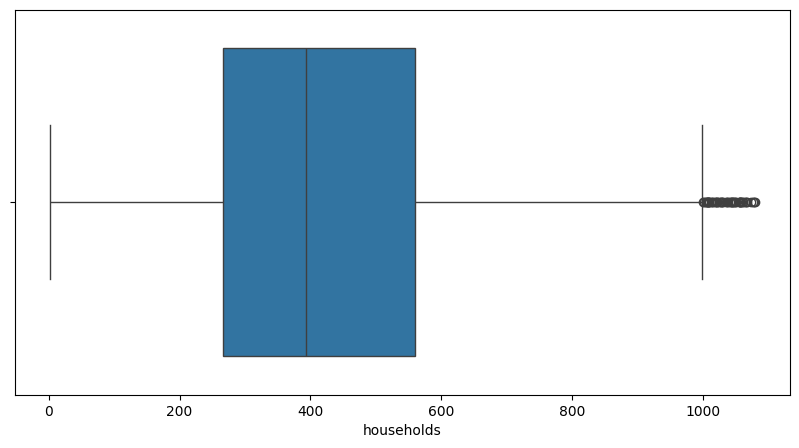

In [31]:
new_dataset=df[(df['households']>=min_value) & (df['households']<=max_value)]
plt.figure(figsize=(10,5))
sns.boxplot(x=new_dataset['households'])
plt.show()

In [31]:
new_dataset.shape

(2841, 9)

/tmp/ipykernel_516/2216490827.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['households'])
/tmp/ipykernel_516/2216490827.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_dataset['households'])


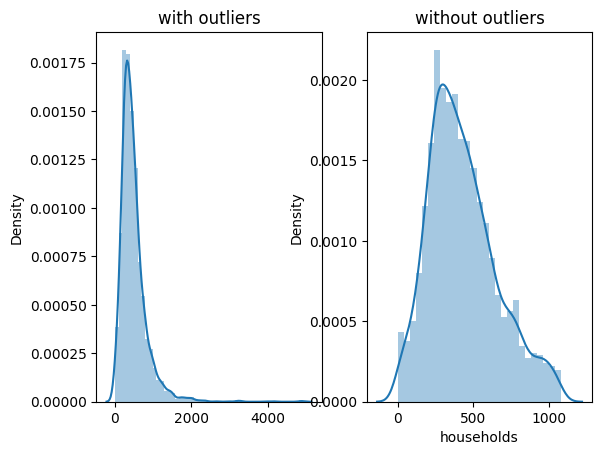

In [34]:
plt.subplot(1,2,1) #subplot(row,column,position)
plt.title('with outliers')
sns.distplot(x=df['households'])

plt.subplot(1,2,2)
plt.title('without outliers')
sns.distplot(new_dataset['households'])
plt.show()


/tmp/ipykernel_1845/1059730962.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_dataset['households'])


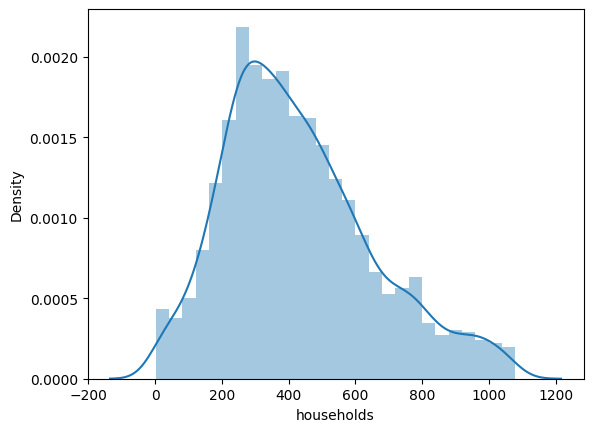

In [4]:
z_score=(df['households']-df['households'].mean())/df['households'].std()
z_score

,households
0,0.317681
1,-0.582646
2,0.013924
3,-1.310570
4,-0.692108
...,...
2995,0.320418
2996,1.494401
2997,-0.738630
2998,-1.302360


In [5]:
df['z_score']=z_score

In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,z_score
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0,0.317681
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0,-0.582646
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0,0.013924
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0,-1.310570
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0,-0.692108


In [35]:
filter_df=df[df['z_score']<2]
filter_df.shape

(2886, 10)

In [36]:
#standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(df[['households']])

StandardScaler()

In [41]:
df['households_scaled']=scaler.transform(df[['households']])
# df.head()
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,z_score,households_scaled
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000,3.000000e+03,3.000000e+03
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500,4.855375e-17,4.855375e-17
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747,1.000000e+00,1.000167e+00
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000,-1.335199e+00,-1.335421e+00
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000,-5.935920e-01,-5.936910e-01
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000,-2.200520e-01,-2.200887e-01
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000,2.937365e-01,2.937855e-01
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000,1.215055e+01,1.215258e+01


/tmp/ipykernel_516/3816936770.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['households_scaled'])


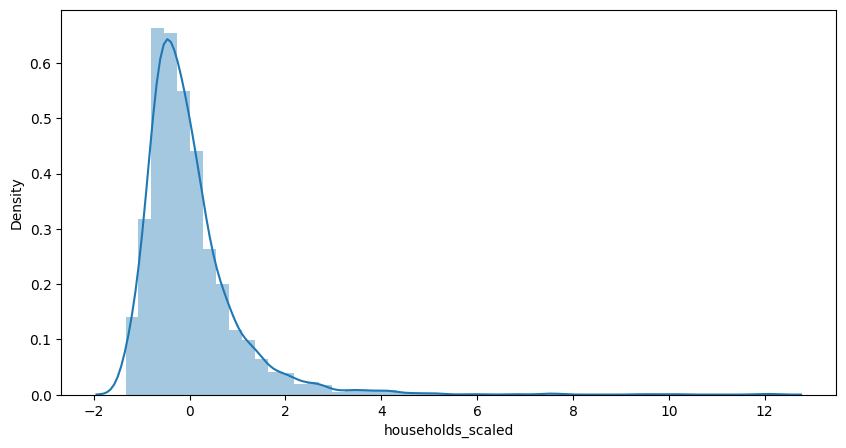

In [40]:
plt.figure(figsize=(10,5))
sns.distplot(df['households_scaled'])
plt.show()